# Análise de métricas — Agentes de Recuperação de Crédito

Gráficos a partir de `historico_negociacao` (tokens, custo, latência, auditoria).

**Pré-requisitos:** `pip install -r requirements.txt` e banco populado (`py app/database/seed_db.py` + negociações no chat).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "app").exists() and (ROOT.parent / "app").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from app.analytics.metrics_loader import (
    load_etapa_summary,
    load_session_summary,
    load_turn_metrics_df,
)

DB_PATH = ROOT / "app" / "database" / "credito.db"
OUT_DIR = ROOT / "notebooks" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

def salvar(fig, nome: str):
    path = OUT_DIR / nome
    fig.savefig(path, bbox_inches="tight")
    print(f"Salvo: {path}")

In [2]:
df = load_turn_metrics_df(DB_PATH)
sessoes = load_session_summary(df)
etapas = load_etapa_summary(df)
llm = df[df["com_llm"]].copy()

print(f"Turnos: {len(df)} | Com LLM: {len(llm)} | Sessões: {df['session_id'].nunique()}")
display(df.head())
display(sessoes.head())

Turnos: 13 | Com LLM: 7 | Sessões: 3


,turno_id,session_id,etapa,data_interacao,custo_estimado_usd,acordo_fechado,resultado_auditoria,cliente_id,cpf,nome,...,negociador_model,negociador_input_tokens,negociador_output_tokens,negociador_latencia_ms,auditor_model,auditor_input_tokens,auditor_output_tokens,auditor_latencia_ms,score_faixa,com_llm
0,1,73e7d111-0e4c-4d2b-bc20-364cf17e4f5c,saudacao,2026-06-29 01:00:22,0.000000,False,etapa_saudacao,1,59126335000,Flavio Silva,...,,0,0,0,,0,0,0,Alto (701+),False
1,2,73e7d111-0e4c-4d2b-bc20-364cf17e4f5c,detalhamento,2026-06-29 01:00:30,0.000000,False,etapa_detalhamento,1,59126335000,Flavio Silva,...,,0,0,0,,0,0,0,Alto (701+),False
2,3,73e7d111-0e4c-4d2b-bc20-364cf17e4f5c,negociacao,2026-06-29 01:01:09,0.001656,False,aprovado,1,59126335000,Flavio Silva,...,gemini-2.5-flash,684,327,2919,gemini-2.5-flash,545,2125,10438,Alto (701+),True
3,4,73e7d111-0e4c-4d2b-bc20-364cf17e4f5c,negociacao,2026-06-29 01:03:28,0.001263,False,aprovado,1,59126335000,Flavio Silva,...,gemini-2.5-flash,793,218,2057,gemini-2.5-flash,532,1555,7216,Alto (701+),True
4,5,73e7d111-0e4c-4d2b-bc20-364cf17e4f5c,negociacao,2026-06-29 01:04:12,0.000989,False,aprovado,1,59126335000,Flavio Silva,...,gemini-2.5-flash,836,112,1306,gemini-2.5-flash,516,1199,5860,Alto (701+),True


,session_id,cpf,nome,score,turnos,inicio,fim,custo_total_usd,acordo_fechado,tokens_total,latencia_media_ms,turnos_com_llm
0,73e7d111-0e4c-4d2b-bc20-364cf17e4f5c,59126335000,Flavio Silva,850,6,2026-06-29 01:00:22,2026-06-29 01:07:02,0.004972,False,12188.0,13155.75,4.0
1,cdf0835e-1584-4e87-8646-b084d480abc9,59126335000,Flavio Silva,850,5,2026-06-29 01:40:26,2026-06-29 01:44:32,0.004902,False,11478.0,12971.00,3.0
2,test-delta-format,59126335000,Flavio Silva,850,2,2026-06-29 01:37:15,2026-06-29 01:37:15,0.000000,False,0.0,0.00,0.0


## 1. Custo total por sessão

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\01_custo_por_sessao.png


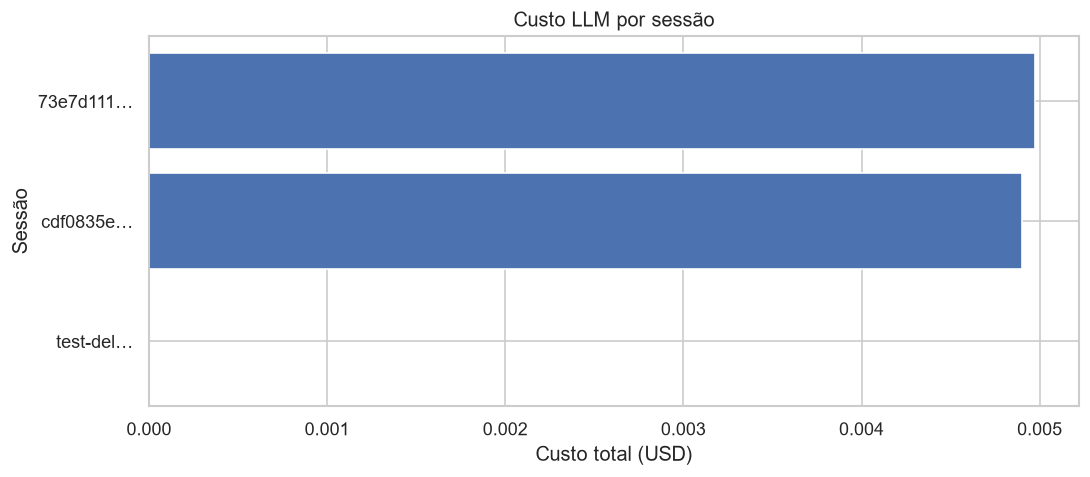

In [3]:
if sessoes.empty:
    print("Sem sessões para plotar.")
else:
    plot_df = sessoes.sort_values("custo_total_usd", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.35)))
    ax.barh(plot_df["session_id"].str[:8] + "…", plot_df["custo_total_usd"])
    ax.set_xlabel("Custo total (USD)")
    ax.set_ylabel("Sessão")
    ax.set_title("Custo LLM por sessão")
    ax.invert_yaxis()
    salvar(fig, "01_custo_por_sessao.png")
    plt.show()

## 2. Tokens por turno (sessão com mais turnos)

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\02_tokens_por_turno.png


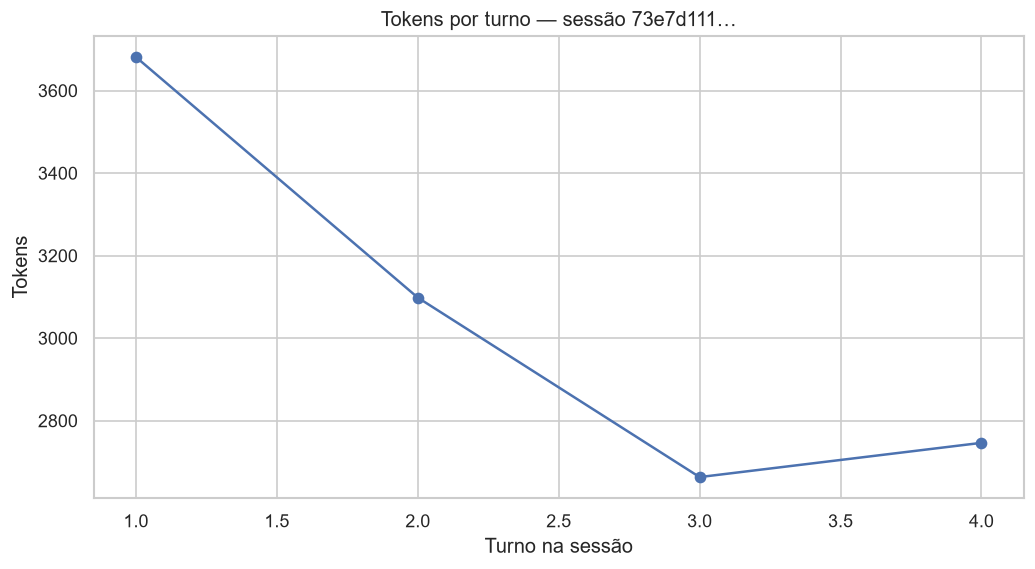

In [4]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    top_session = llm["session_id"].value_counts().idxmax()
    s = llm[llm["session_id"] == top_session].copy()
    s["turno_idx"] = range(1, len(s) + 1)

    fig, ax = plt.subplots()
    ax.plot(s["turno_idx"], s["total_tokens"], marker="o")
    ax.set_xlabel("Turno na sessão")
    ax.set_ylabel("Tokens")
    ax.set_title(f"Tokens por turno — sessão {top_session[:8]}…")
    salvar(fig, "02_tokens_por_turno.png")
    plt.show()

## 3. Latência média por etapa

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\03_latencia_por_etapa.png


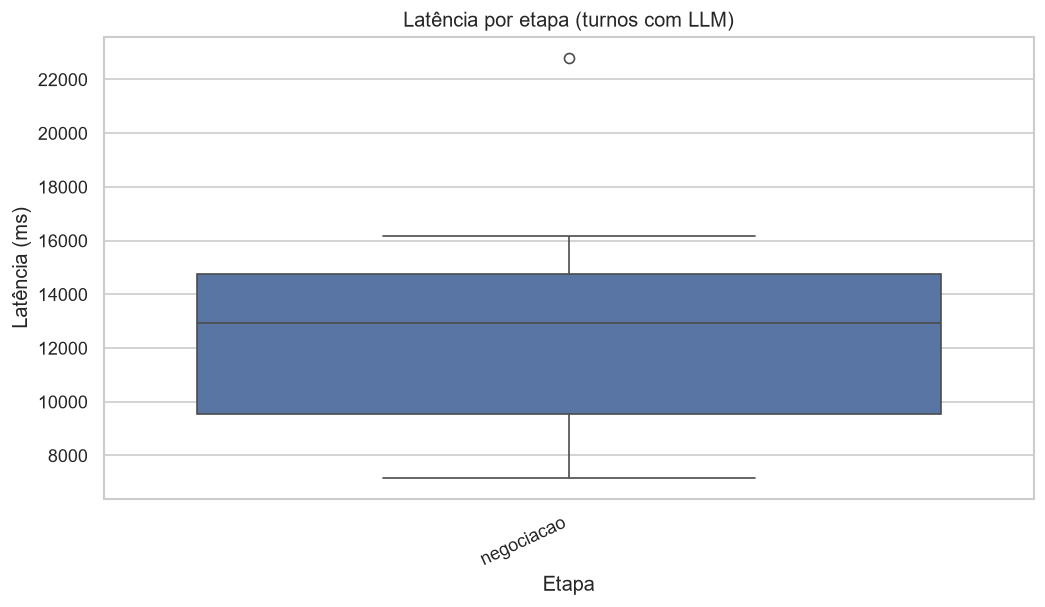

In [5]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = llm.groupby("etapa")["total_latencia_ms"].median().sort_values().index
    sns.boxplot(data=llm, x="etapa", y="total_latencia_ms", order=order, ax=ax)
    ax.set_xlabel("Etapa")
    ax.set_ylabel("Latência (ms)")
    ax.set_title("Latência por etapa (turnos com LLM)")
    plt.xticks(rotation=25, ha="right")
    salvar(fig, "03_latencia_por_etapa.png")
    plt.show()

## 4. Tokens: negociador vs auditor

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\04_tokens_por_agente.png


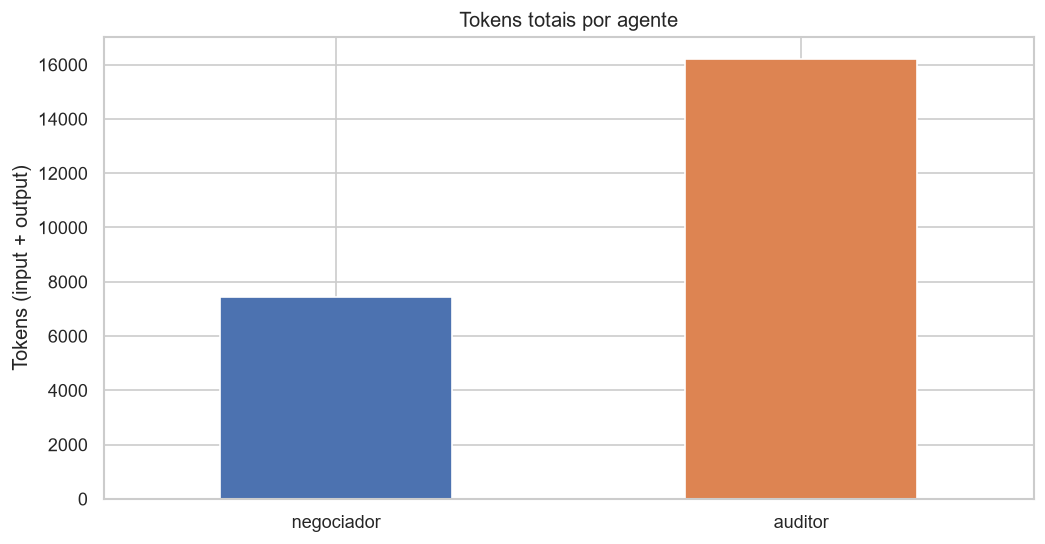

In [6]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    agent_df = llm[["turno_id", "negociador_input_tokens", "negociador_output_tokens",
                    "auditor_input_tokens", "auditor_output_tokens"]].copy()
    agent_df["negociador"] = agent_df["negociador_input_tokens"] + agent_df["negociador_output_tokens"]
    agent_df["auditor"] = agent_df["auditor_input_tokens"] + agent_df["auditor_output_tokens"]
    totais = agent_df[["negociador", "auditor"]].sum()

    fig, ax = plt.subplots()
    totais.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_ylabel("Tokens (input + output)")
    ax.set_title("Tokens totais por agente")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    salvar(fig, "04_tokens_por_agente.png")
    plt.show()

## 5. Tokens × latência (scatter)

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\05_tokens_vs_latencia.png


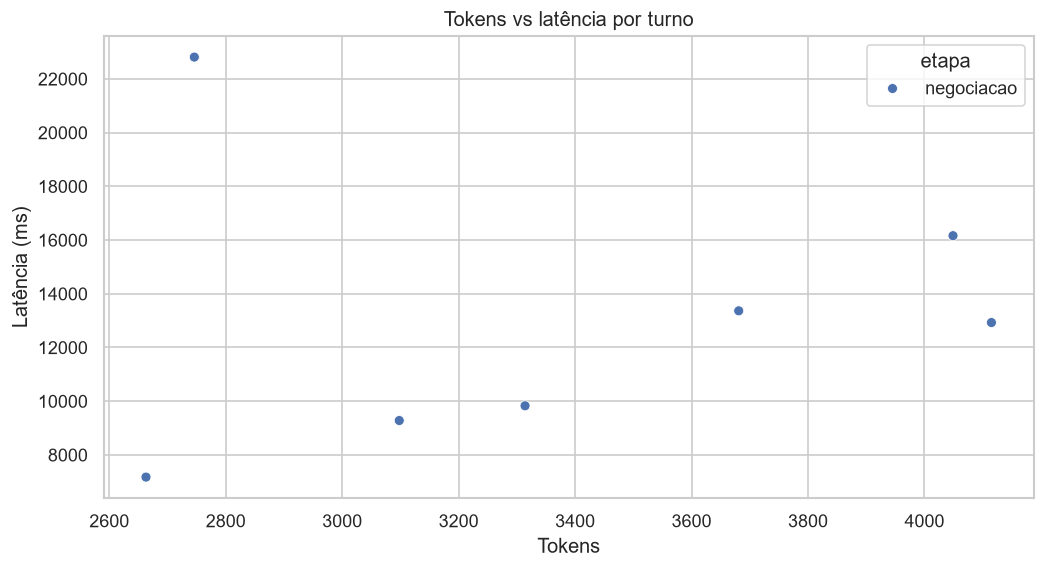

In [7]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    fig, ax = plt.subplots()
    sns.scatterplot(data=llm, x="total_tokens", y="total_latencia_ms", hue="etapa", ax=ax)
    ax.set_xlabel("Tokens")
    ax.set_ylabel("Latência (ms)")
    ax.set_title("Tokens vs latência por turno")
    salvar(fig, "05_tokens_vs_latencia.png")
    plt.show()

## 6. Resultado da auditoria

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\06_resultado_auditoria.png


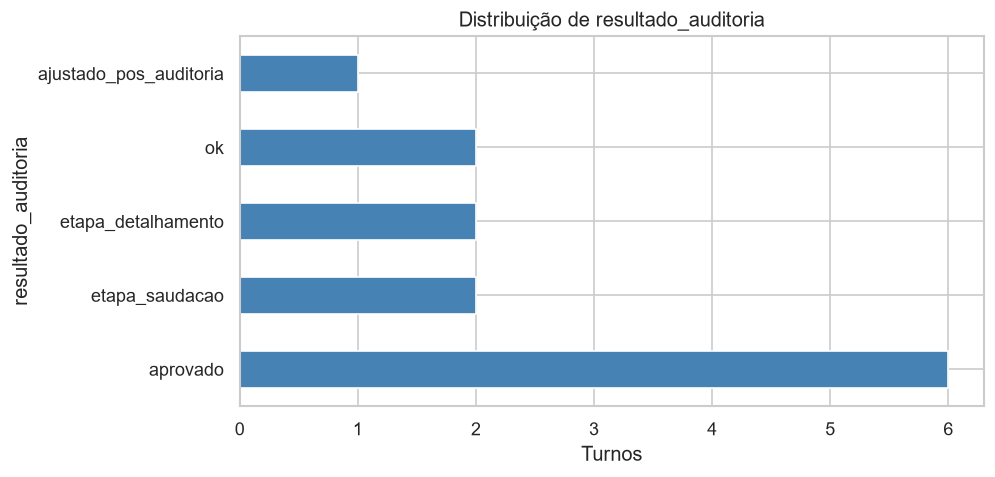

In [8]:
if df.empty:
    print("Sem dados.")
else:
    aud = df["resultado_auditoria"].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    aud.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Turnos")
    ax.set_title("Distribuição de resultado_auditoria")
    salvar(fig, "06_resultado_auditoria.png")
    plt.show()

## 7. Custo médio por faixa de score

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\07_custo_por_score.png


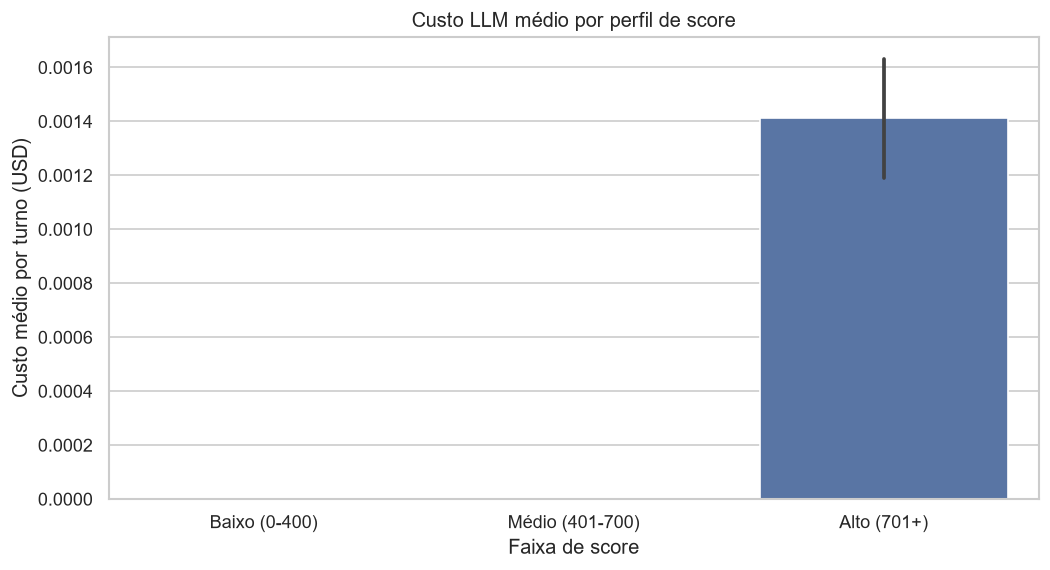

In [9]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    fig, ax = plt.subplots()
    sns.barplot(data=llm, x="score_faixa", y="custo_estimado_usd", estimator="mean", ax=ax)
    ax.set_xlabel("Faixa de score")
    ax.set_ylabel("Custo médio por turno (USD)")
    ax.set_title("Custo LLM médio por perfil de score")
    salvar(fig, "07_custo_por_score.png")
    plt.show()

## 8. Gráfico interativo (Plotly) — custo acumulado na sessão

Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\08_custo_acumulado.html


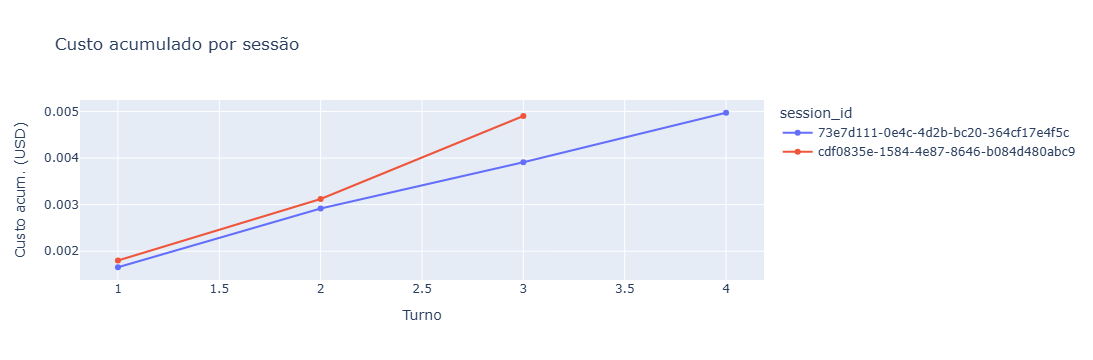

In [10]:
import plotly.express as px

if llm.empty:
    print("Sem turnos com LLM.")
else:
    p = llm.copy()
    p["turno_idx"] = p.groupby("session_id").cumcount() + 1
    p["custo_acum_usd"] = p.groupby("session_id")["custo_estimado_usd"].cumsum()
    fig = px.line(
        p, x="turno_idx", y="custo_acum_usd", color="session_id",
        markers=True, title="Custo acumulado por sessão",
        labels={"turno_idx": "Turno", "custo_acum_usd": "Custo acum. (USD)"},
    )
    html_path = OUT_DIR / "08_custo_acumulado.html"
    fig.write_html(html_path)
    print(f"Salvo: {html_path}")
    fig.show()